In [1]:

def normalize_style(style):
    s = style
    if s in ["Even 8th's", "Even 8's"]:
        return 'Even 8ths'
    if 'Swing' in s or 'Fusion' in s or 'Jazz' in s:
        return 'Jazz'
    if 'Blues' in s:
        return 'Blues'
    if 'Folk' in s:
        return 'Folk'
    if 'Bossa' in s:
        return 'Bossa'
    if 'Reggae' in s:
        return 'Reggae'
    if 'Samba' in s:
        return 'Samba'
    if 'Funk' in s:
        return 'Funk'
    if 'Pop' in s:
        return 'Pop'
    if 'Son' in s:
        return 'Son'
    if 'Rock' in s or s == 'Beatles':
        return 'Rock'
    if 'Soul' in s:
        return 'Soul'
    if 'Balad' in s:
        return 'Balad'
    if s == "R'n'B":
        return "RnB"
    if s == 'Afoxe':
        return 'Afoxé'
    if s in ['Worship', 'Traditional Gospel']:
        return 'Gospel'
    if s == 'Even 8ths':
        return 'Pop'
    return s

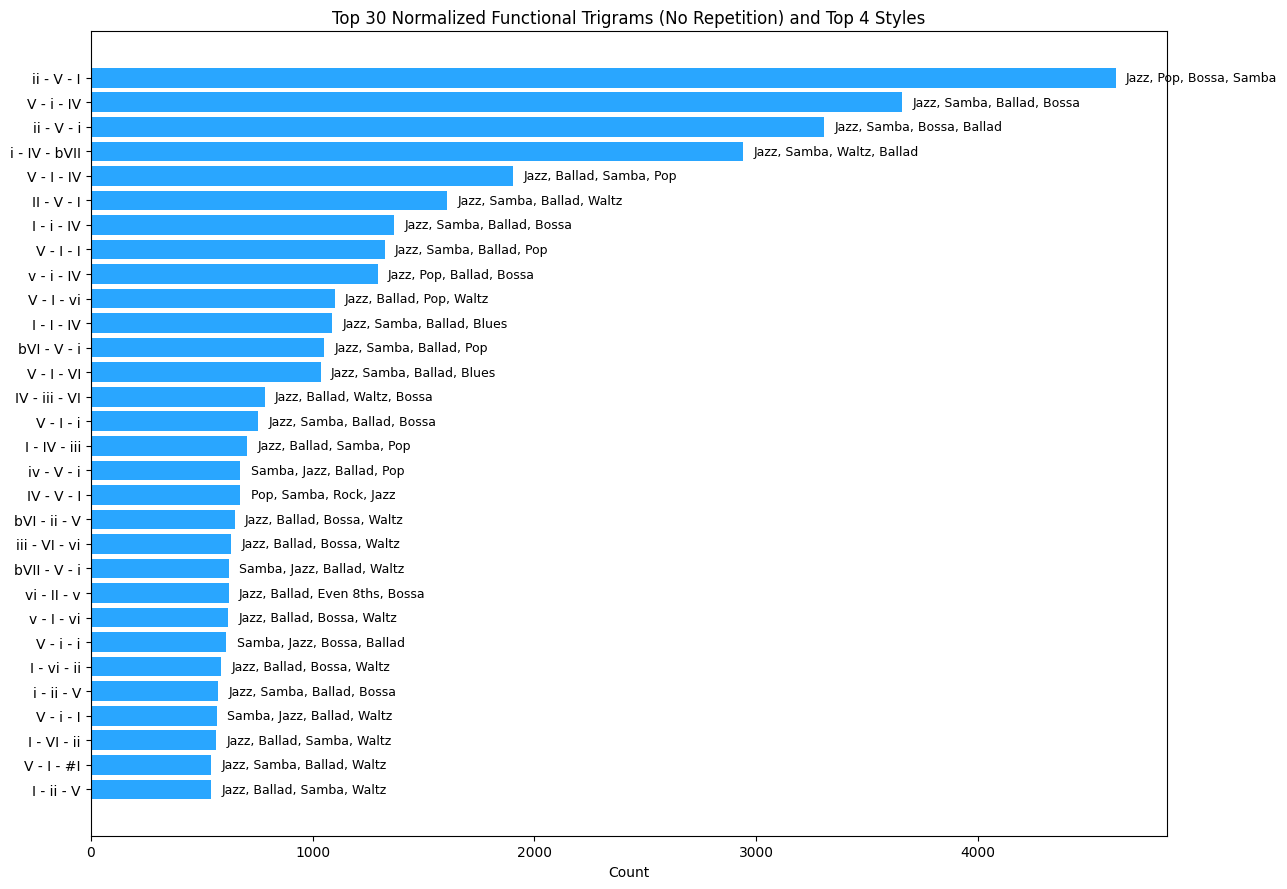

In [2]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

def normalize_function_label(label):
    # Remove accidentals, extensions, and alterations: keep only Roman numerals and accidentals at start
    match = re.match(r"([b#♭♯]*[IViv]+)", label)
    return match.group(1) if match else label

def normalize_trigram(function_trigram):
    # Return canonicalized tuple of roman numerals
    return tuple(normalize_function_label(x) for x in function_trigram)

# Load data
with open('/workspace/dataset/trigrams/trigram_dataset.json', 'r') as f:
    data = json.load(f)

# Aggregate: trigram -> count, style counter
trigram_count = Counter()
trigram_styles = defaultdict(Counter)

for entry in data:
    func_trigram = normalize_trigram(entry['function'])
    if len(set(func_trigram)) == 1:
        continue
    count = entry['count']
    for style in entry['styles']:
        norm_style = normalize_style(style)
        trigram_styles[func_trigram][norm_style] += count
    trigram_count[func_trigram] += count

# Select top 
selected = 30
top_trigrams = trigram_count.most_common(selected)

# Prepare for plotting
plot_labels = []
plot_counts = []
plot_topstyles = []

num_styles = 4
for trigram, count in top_trigrams:
    roman_label = ' - '.join(trigram)
    styles_counter = trigram_styles[trigram]
    top_n_styles = [s for s, _ in styles_counter.most_common(num_styles)]
    plot_labels.append(roman_label)
    plot_counts.append(count)
    plot_topstyles.append(', '.join(top_n_styles))

# Reverse for horizontal plot (most common at top)
plot_labels = plot_labels[::-1]
plot_counts = plot_counts[::-1]
plot_topstyles = plot_topstyles[::-1]

# Plot
fig, ax = plt.subplots(figsize=(13, 9))
bars = ax.barh(plot_labels, plot_counts, color="#29a6ff")

for i, (c, styles) in enumerate(zip(plot_counts, plot_topstyles)):
    ax.text(c + max(plot_counts) * 0.01, i, styles, va='center', fontsize=9, color="#000000")

ax.set_xlabel('Count')
ax.set_title(f'Top {selected} Normalized Functional Trigrams (No Repetition) and Top {num_styles} Styles')
plt.tight_layout()
plt.show()


/tmp/ipykernel_2412095/2037479474.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=text_size)
/tmp/ipykernel_2412095/2037479474.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=text_size)


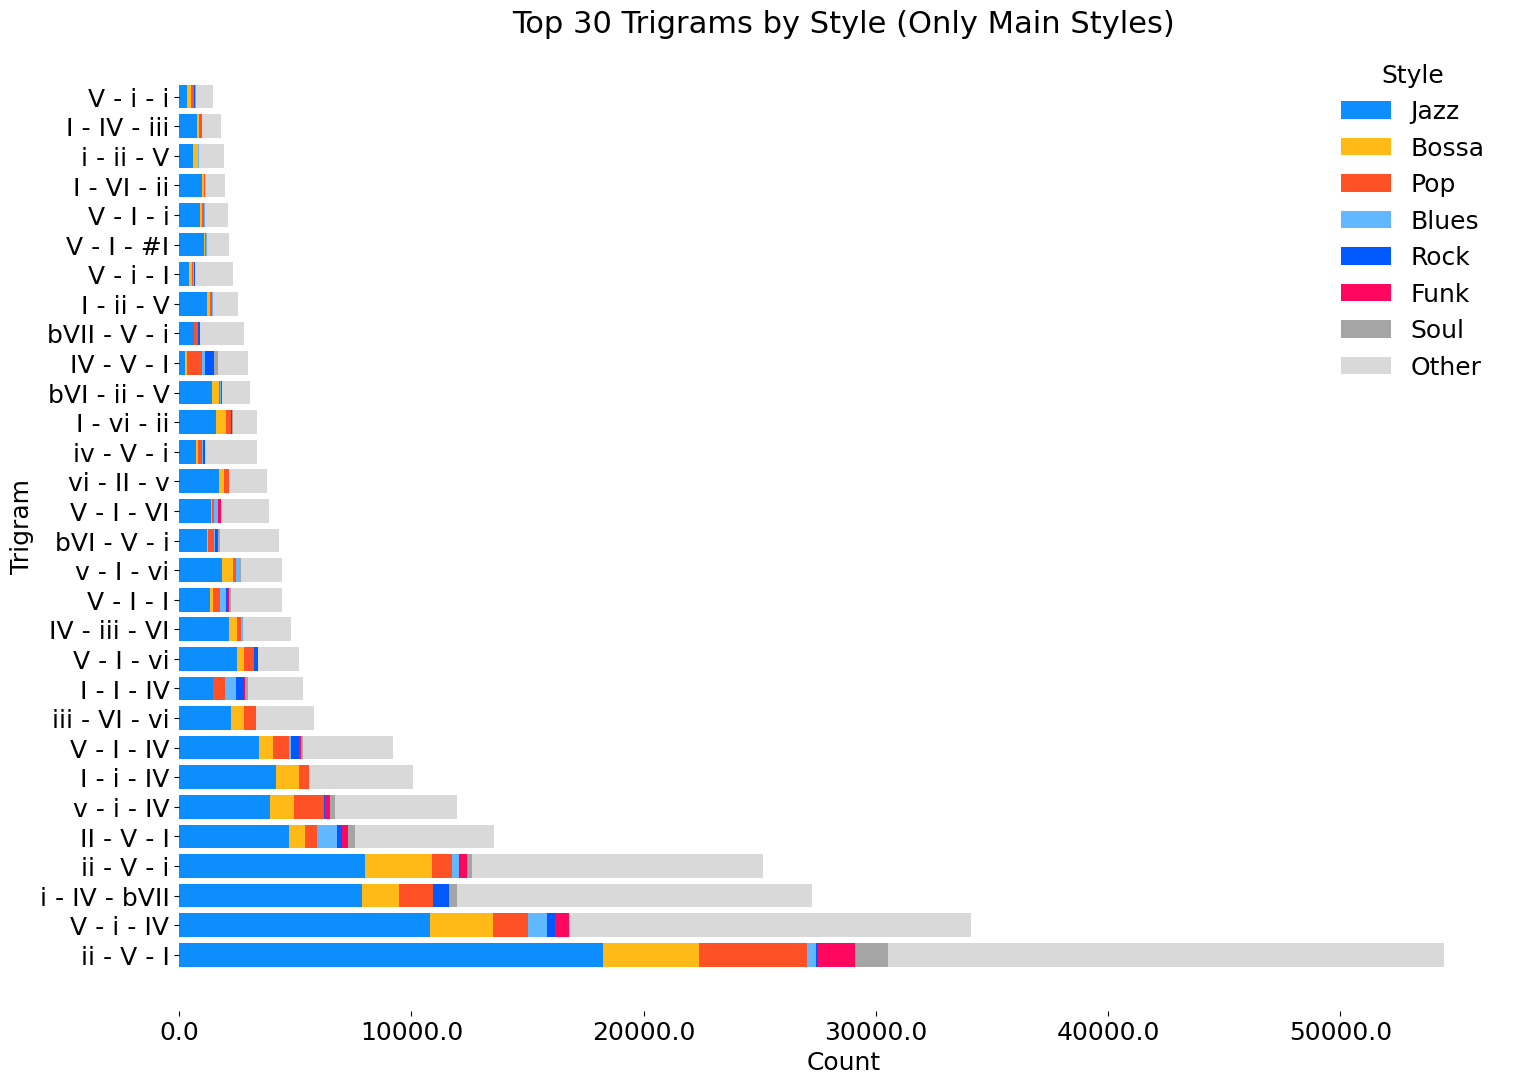

In [3]:
import numpy as np
import matplotlib.pyplot as plt

N = 30
chosen_styles = ['Jazz', 'Bossa', 'Pop', 'Blues', 'Rock', 'Funk', 'Soul']

# Get top N trigrams
top_trigrams = sorted(trigram_count.items(), key=lambda x: x[1], reverse=True)[:N]
labels = [' - '.join(trigram) for trigram, _ in top_trigrams]

# Build the data matrix and compute total counts for sorting
data = []
totals = []
for trigram, _ in top_trigrams:
    style_counts = trigram_styles[trigram]
    row = [style_counts.get(style, 0) for style in chosen_styles]
    other_count = sum(v for k, v in style_counts.items() if k not in chosen_styles)
    row.append(other_count)
    data.append(row)
    totals.append(sum(row))
data = np.array(data)

# Sort by total count (descending)
sorted_idx = np.argsort(totals)[::-1]
data = data[sorted_idx]
labels = [labels[i] for i in sorted_idx]

# Custom colors for these genres
custom_palette = {
    'Jazz': "#0c8eff",
    'Bossa': "#ffba18",
    'Pop': "#ff5125",
    'Blues': "#61b8ff",
    'Rock': "#0059ff",
    'Funk': "#ff075e",
    'Soul': "#a5a5a5",
    'Other': "#d9d9d9",
}
bar_colors = [custom_palette.get(style, '#636e72') for style in chosen_styles + ['Other']]

# Plot
fig, ax = plt.subplots(figsize=(15, 10))
left = np.zeros(len(labels))
for i, (style, color) in enumerate(zip(chosen_styles + ['Other'], bar_colors)):
    ax.barh(labels, data[:, i], left=left, label=style, color=color)
    left += data[:, i]

# Remove frame
for spine in ax.spines.values():
    spine.set_visible(False)
text_size = 18
# Set bigger font sizes
ax.set_xlabel('Count', fontsize=text_size)
ax.set_ylabel('Trigram', fontsize=text_size)
ax.set_title(f'Top {N} Trigrams by Style (Only Main Styles)', fontsize=22)
ax.set_yticklabels(labels, fontsize=text_size)
ax.set_xticklabels(ax.get_xticks(), fontsize=text_size)

# Legend with bigger font
ax.legend(title='Style', fontsize=text_size, title_fontsize=text_size, loc='upper right', frameon=False)

plt.tight_layout(pad=0.1)
plt.subplots_adjust(bottom=0.01, top=0.98)
plt.show()



In [4]:
import re

def split_function_label(label):
    match = re.match(r"^([b#♭♯]*[IViv]+)(.*)$", label)
    if match:
        degree = match.group(1)
        extension = match.group(2)
        return degree, extension
    else:
        return label, ""

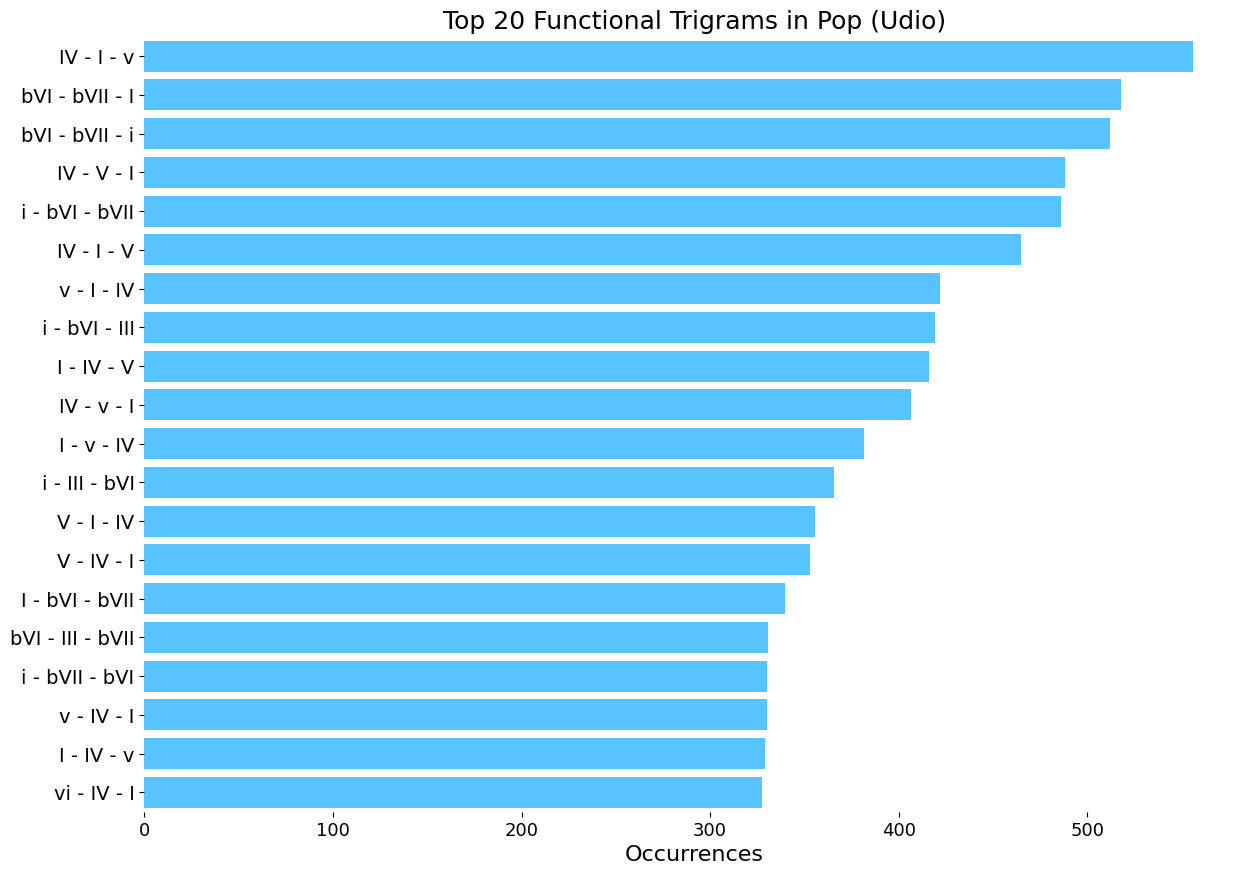

In [23]:
import json
import matplotlib.pyplot as plt

collection = 'udio'
path = f'/workspace/ngram_datasets/trigrams/3gram_dataset_{collection}.json'
# Load the data
with open(path, 'r') as f:
    data = json.load(f)

# Extract trigrams with Pop in styles, and get their Pop count
pop_trigrams = []
style = 'pop'
for entry in data:
    for s, count in entry['dortmund_genres']:
        if s == style:
            pop_trigrams.append({
                "function": entry['ngram'],
                "pop_count": count
            })
            break

N = 20
# Sort by Pop count, descending
pop_trigrams = sorted(pop_trigrams, key=lambda x: x['pop_count'], reverse=True)[:N]

# Prepare data for plotting
labels = [' - '.join(tri['function']) for tri in pop_trigrams]
counts = [tri['pop_count'] for tri in pop_trigrams]

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(labels[::-1], counts[::-1], color="#58c4ff")

# Remove all spines (the box/frame)
for spine in ax.spines.values():
    spine.set_visible(False)

# Tighten layout
plt.tight_layout(pad=0.05)

# Set y-limits to crop empty space
ax.set_ylim(-0.5, len(labels) - 0.5)  # Half-bar padding

ax.set_xlabel('Occurrences', fontsize=16)
ax.set_title('Top 20 Functional Trigrams in {} ({})'.format(style.capitalize(), collection.capitalize()), fontsize=18)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=13)

plt.show()

In [6]:
from trigram_search import query_trigram_usage

result = query_trigram_usage(["ii", "V", "I"])
print(result)


{'functional_trigrams': {'count': 4620, 'styles': [['Jazz', 18241], ['Pop', 4641], ['Bossa', 4151], ['Samba', 4031], ['Ballad', 4030], ['Latin', 3201], ['Waltz', 3197], ['Bolero', 1814], ['Gospel', 1619], ['Funk', 1597]], 'matched': 'exact', 'function': ['ii', 'V', 'I']}, 'trigram_dataset': {'total_count': 10298, 'styles': [('Medium Swing', 8565), ('Ballad', 8160), ('Samba', 6991), ('Medium Up Swing', 6639), ('Up Tempo Swing', 6534), ('Waltz', 6392), ('Bossa Nova', 6231), ('Slow Swing', 5713), ('Latin', 5194), ('Even 8ths', 2645)], 'composers': [('Richard Rodgers', 5151), ('Harold Arlen', 5005), ('Cole Porter', 4630), ('George Gershwin', 4550), ('Duke Ellington', 4444), ('Exercise', 4430), ('Antonio-Carlos Jobim', 4319), ('Jimmy Van-Heusen', 4199), ('Hoagy Carmichael', 3941), ('Frank Loesser', 3886)]}}


{'functional_trigrams': {'count': 674, 'styles': [['Pop', 680], ['Samba', 441], ['Rock', 403], ['Jazz', 270], ['Soul', 150], ['Gospel', 137], ['Folk', 123], ['Ballad', 103], ['Blues', 102], ['Latin', 82]], 'matched': 'exact', 'function': ['IV', 'V', 'I']}, 'trigram_dataset': {'total_count': 1817, 'styles': [('Samba', 924), ('Medium Swing', 642), ('Ballad', 462), ('Samba Enredo', 407), ('Rock Pop', 395), ('Rock', 357), ('Pop', 308), ('Up Tempo Swing', 226), ('Latin', 209), ('Waltz', 203)], 'composers': [('The Beatles (Lennon, McCartney)', 295), ('Nelson Cavaquinho', 276), ('Zeca Pagodinho', 235), ('Fundo de Quintal', 218), ('Roberto Ribeiro', 184), ('Gonzaguinha', 173), ('João Nogueira', 171), ('Martinho da Vila', 160), ('Chico Buarque', 149), ('GRES Salgueiro 2010', 146)]}}


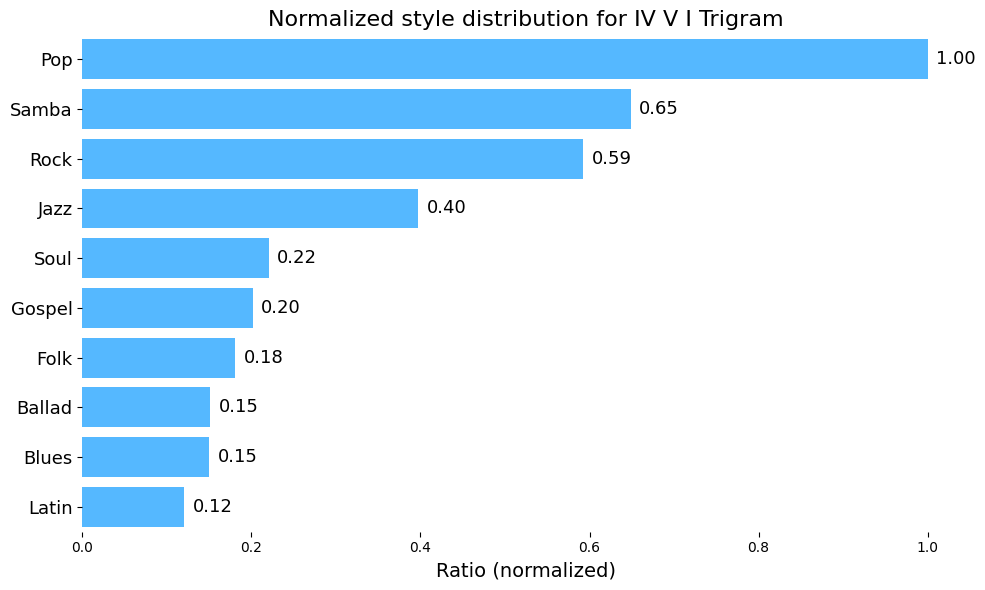

In [7]:
import matplotlib.pyplot as plt

find = ["IV", "V", "I"]

result = query_trigram_usage(find)

print(result)

styles_counts = result["functional_trigrams"]["styles"]
if not styles_counts:
    print("No styles to plot.")
else:
    labels, counts = zip(*styles_counts)
    counts = list(counts)
    max_count = max(counts)
    norm_counts = [c / max_count for c in counts]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(labels[::-1], norm_counts[::-1], color="#55b8ff", edgecolor="none")

    # Remove frame
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_ylim(-0.5, len(labels) - 0.5)

    # Add ratio labels
    for bar in bars:
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{bar.get_width():.2f}", va='center', fontsize=13)

    ax.set_xlabel("Ratio (normalized)", fontsize=14)
    ax.set_title('Normalized style distribution for ' + ' '.join(find) + ' Trigram', fontsize=16)
    ax.tick_params(axis='y', labelsize=13)
    plt.tight_layout()
    plt.show()


In [88]:
import json
from collections import Counter

type = "suno"
path = f"/workspace/ngram_datasets/trigrams/3gram_dataset_{type}.json"

with open(path) as f:
    trigram_data = json.load(f)

genre_counter = Counter()

for entry in trigram_data:
    # entry['genres'] is a list of [genre, weight]
    for genre, weight in entry.get('genres', []):
        genre_counter[genre] += weight

# Print top N genres
N = 30
print("Most common Dortmund genres in", type, "trigrams:")
for genre, weight in genre_counter.most_common(N):
    print(f"{genre:15} {weight:.2f}")


Most common Dortmund genres in suno trigrams:


In [89]:
from collections import defaultdict
import numpy as np

N = 30
# Include 'pop' and any other Dortmund genres you care about
chosen_styles = ['rock', 'electronic', 'jazz', 'pop', 'alternative', 'raphiphop', 'folkcountry', 'funksoulrnb', 'blues']

trigram_count = {}
trigram_genres = defaultdict(dict)

for entry in trigram_data:
    trigram = tuple(entry['ngram'])
    count = entry['count']
    trigram_count[trigram] = count
    # genres is a list of [genre, float sum]
    genre_counts = {k.lower(): v for k, v in entry['dortmund_genres']}  # always lowercase for safety
    trigram_genres[trigram] = genre_counts

# Get top N trigrams by total count
top_trigrams = sorted(trigram_count.items(), key=lambda x: x[1], reverse=True)[:N]
labels = [' - '.join(trigram) for trigram, _ in top_trigrams]

# Build data matrix (main genres + 'other')
data = []
totals = []
for trigram, _ in top_trigrams:
    genre_counts = trigram_genres[trigram]
    row = [genre_counts.get(style, 0) for style in chosen_styles]
    # "other" is sum of all dormund genres not in chosen_styles
    other_count = sum(v for k, v in genre_counts.items() if k not in chosen_styles)
    row.append(other_count)
    data.append(row)
    totals.append(sum(row))
data = np.array(data)

# Sort by total count (descending) (this actually does nothing since already sorted)
sorted_idx = np.argsort(totals)[::-1]
data = data[sorted_idx]
labels = [labels[i] for i in sorted_idx]


/tmp/ipykernel_2412095/1333933885.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=text_size)
/tmp/ipykernel_2412095/1333933885.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=text_size)


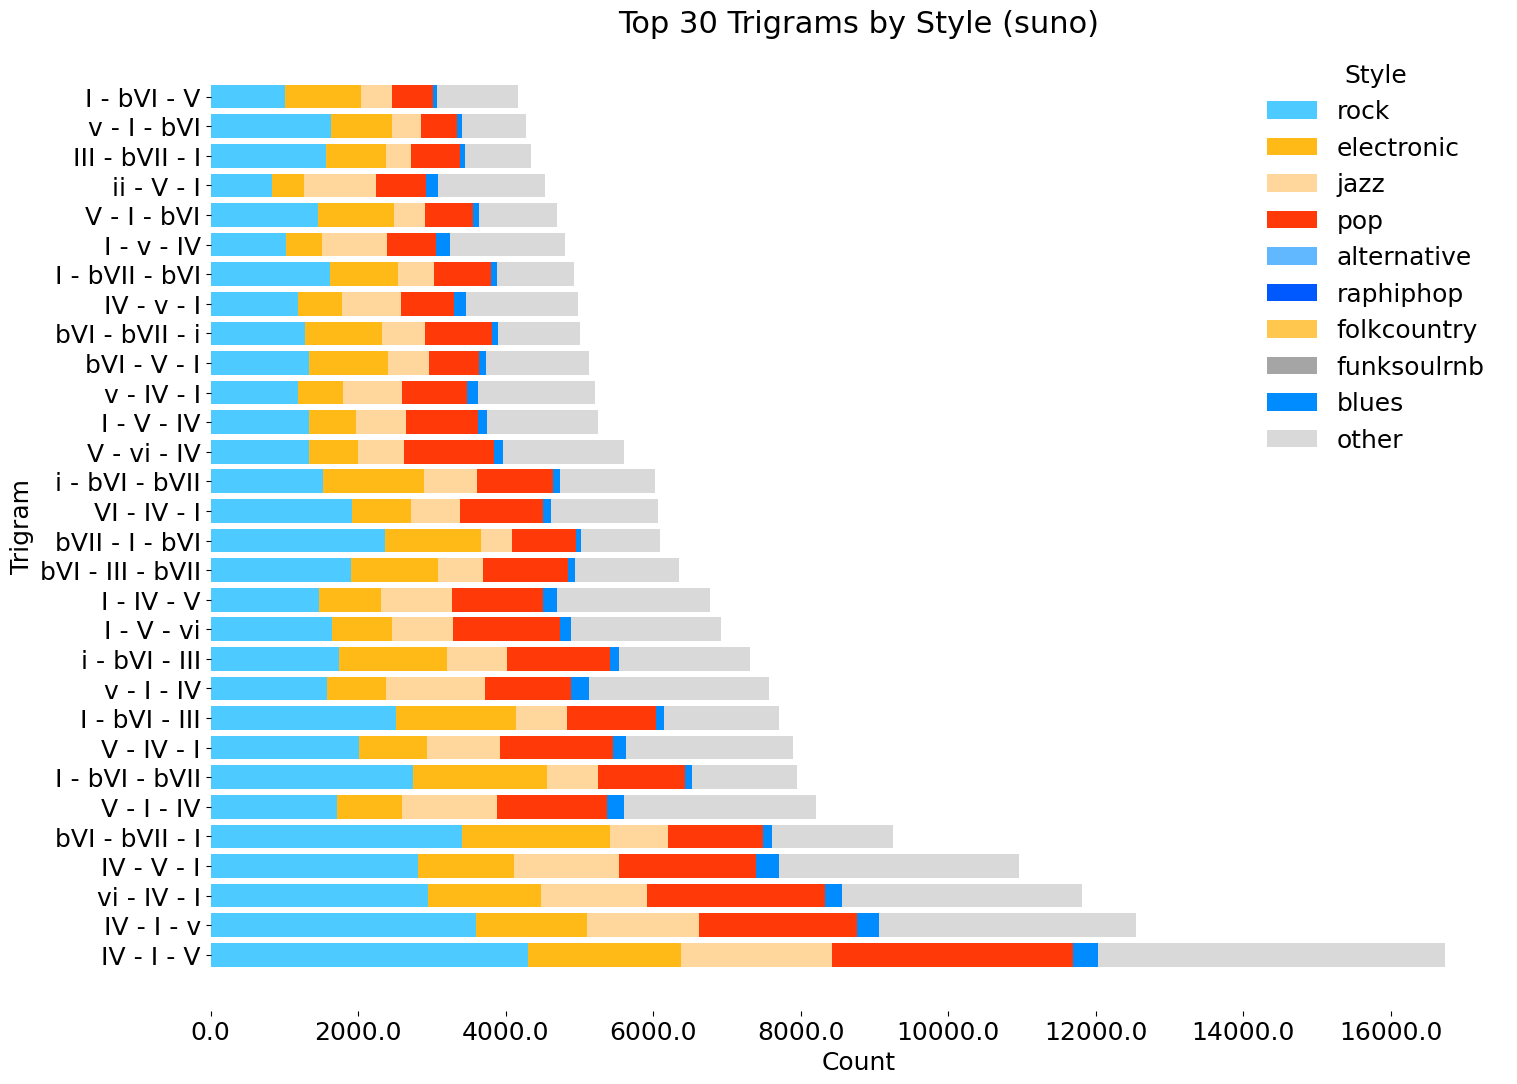

In [90]:
import matplotlib.pyplot as plt


custom_palette = {
    'rock': "#4dcaff",
    'electronic': "#ffba18",
    'jazz': "#ffd69c",
    'pop': "#ff3907",
    'alternative': "#61b8ff",
    'raphiphop': "#0059ff",
    'folkcountry': "#ffc74e",
    'funksoulrnb': "#a5a5a5",
    'blues': "#008cff",
    'other': "#d9d9d9",
}
bar_colors = [custom_palette.get(style, '#636e72') for style in chosen_styles + ['other']]

fig, ax = plt.subplots(figsize=(15, 10))
left = np.zeros(len(labels))
for i, (style, color) in enumerate(zip(chosen_styles + ['other'], bar_colors)):
    ax.barh(labels, data[:, i], left=left, label=style, color=color)
    left += data[:, i]

for spine in ax.spines.values():
    spine.set_visible(False)
text_size = 18
ax.set_xlabel('Count', fontsize=text_size)
ax.set_ylabel('Trigram', fontsize=text_size)
ax.set_title(f'Top {N} Trigrams by Style ({type})', fontsize=22)
ax.set_yticklabels(labels, fontsize=text_size)
ax.set_xticklabels(ax.get_xticks(), fontsize=text_size)
ax.legend(title='Style', fontsize=text_size, title_fontsize=text_size, loc='upper right', frameon=False)

plt.tight_layout(pad=0.1)
plt.subplots_adjust(bottom=0.01, top=0.98)
plt.show()


In [20]:
import json

type = "suno"
path = f"/workspace/ngram_datasets/trigrams/3gram_dataset_{type}.json"

with open(path) as f:
    trigram_data = json.load(f)

first_entry = trigram_data[0]

/tmp/ipykernel_2571050/3388337326.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=text_size)
/tmp/ipykernel_2571050/3388337326.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=text_size)


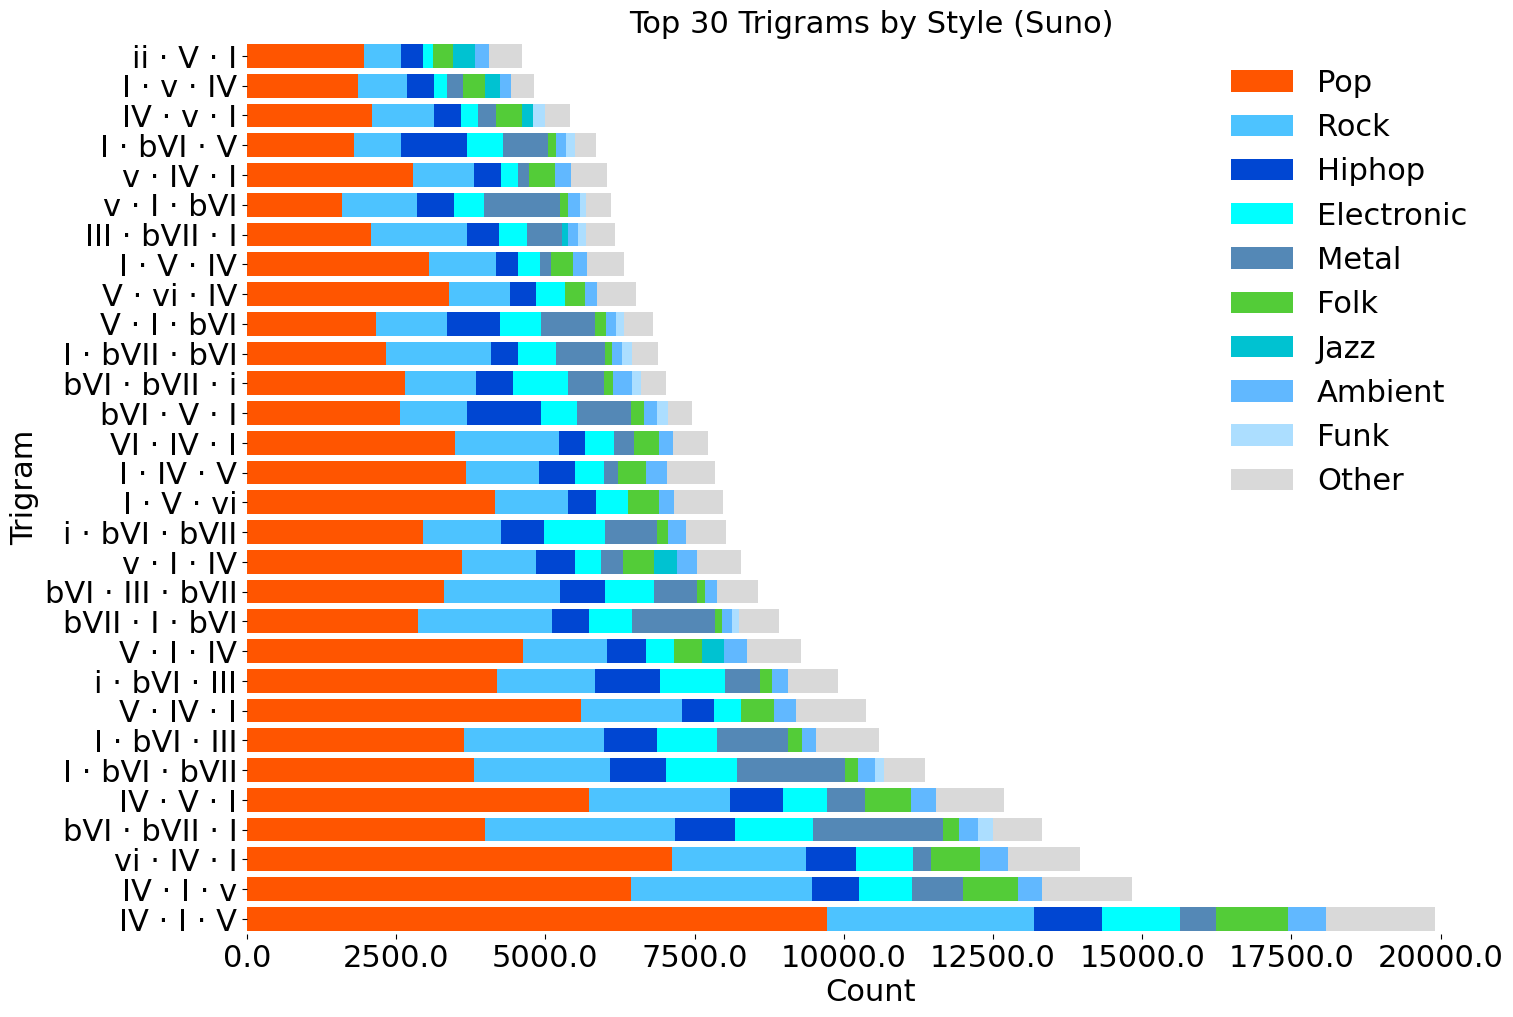

In [21]:
import json
from collections import defaultdict, Counter
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Load
with open(path) as f:
    trigram_data = json.load(f)

# Build all_styles
all_styles = Counter()
for entry in trigram_data:
    for style, count in entry.get('human_styles', []):
        all_styles[style.lower()] += count

N_styles = 9  # top N
chosen_styles = [s for s, _ in all_styles.most_common(N_styles)]

custom_palette = {
    'pop':      "#FF5500",
    'rock':     "#4DC3FF",
    'electronic': "#00FFFF",
    'hiphop':   "#0046D2",
    'country':  "#FFB366",
    'ambient':  "#61B8FF",
    'metal':    "#5488B6",
    'punk':     "#BCBCBC",
    'soul':     "#FF844B",
    'dance':    "#0059FF",
    'folk':     "#53CC38",
    'funk':     "#ACDEFF",
    'blues':    "#69E1FF",
    'jazz':     "#00C2D1",
    'rnb':      "#FF7C40",
    'other':    "#d9d9d9",
}

all_plot_styles = chosen_styles + ['other']
bar_colors = [custom_palette.get(style, "#dddddd") for style in all_plot_styles]


# (Rest of your matrix-building and plotting code—unchanged)
trigram_count = {}
trigram_styles = defaultdict(dict)

for entry in trigram_data:
    trigram = tuple(entry['ngram'])
    count = entry['count']
    trigram_count[trigram] = count
    style_counts = {k.lower(): v for k, v in entry['human_styles']}
    trigram_styles[trigram] = style_counts

N = 30
top_trigrams = sorted(trigram_count.items(), key=lambda x: x[1], reverse=True)[:N]
labels = [' · '.join(trigram) for trigram, _ in top_trigrams]

data = []
totals = []
for trigram, _ in top_trigrams:
    style_counts = trigram_styles[trigram]
    row = [style_counts.get(style, 0) for style in chosen_styles]
    other_count = sum(v for k, v in style_counts.items() if k not in chosen_styles)
    row.append(other_count)
    data.append(row)
    totals.append(sum(row))
data = np.array(data)
sorted_idx = np.argsort(totals)[::-1]
data = data[sorted_idx]
labels = [labels[i] for i in sorted_idx]

fig, ax = plt.subplots(figsize=(15, 10))
left = np.zeros(len(labels))
for i, (style, color) in enumerate(zip(all_plot_styles, bar_colors)):
    ax.barh(labels, data[:, i], left=left, label=style, color=color)
    left += data[:, i]

for spine in ax.spines.values():
    spine.set_visible(False)
text_size = 22

ax.set_xlabel('Count', fontsize=text_size)
ax.set_ylabel('Trigram', fontsize=text_size)
ax.set_title(f'Top {N} Trigrams by Style ({type.capitalize()})', fontsize=22)
ax.set_yticklabels(labels, fontsize=text_size)
ax.set_xticklabels(ax.get_xticks(), fontsize=text_size)
# Capitalize style names for legend labels
capitalized_labels = [style.capitalize() for style in all_plot_styles]
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, capitalized_labels, title='', fontsize=text_size, title_fontsize=text_size, loc='upper right', frameon=False)
ax.set_ylim(-0.5, len(labels) - 0.5)


plt.tight_layout(pad=0.1)
plt.show()


In [74]:
trigram_targets = [
    ('I', 'V', 'vi'),
    ('vi', 'IV', 'I'),
    ('IV', 'I', 'V'),
    ('IV', 'I', 'v'),
    ('IV', 'V', 'I'),
    ('V', 'I', 'IV'),
    ('VI', 'IV', 'I'),
    ('V', 'vi', 'IV'),
    ('V', 'I', 'bVI'),
    ('IV', 'v', 'I'),
    ('I', 'v', 'IV'),
    ('ii', 'V', 'I')
]
# If you want all rotations for each, also do:
all_target_trigrams = set()
for tri in trigram_targets:
    for i in range(3):
        all_target_trigrams.add(tuple(list(tri[i:]) + list(tri[:i])))


In [75]:
from collections import defaultdict, Counter
import json

collections = ['lastfm', 'suno', 'udio']
style_collection_trigram_counts = defaultdict(lambda: defaultdict(Counter))
total_style_collection_counts = defaultdict(lambda: defaultdict(int))

# Count for each collection
for collection in collections:
    with open(f"../ngram_datasets/trigrams/3gram_dataset_{collection}.json") as f:
        trigram_data = json.load(f)
    for entry in trigram_data:
        trigram = tuple(entry['ngram'])
        style_counts = entry.get('human_styles', [])
        if trigram in all_target_trigrams:
            for style, count in style_counts:
                style_collection_trigram_counts[trigram][collection][style] += count
        for style, count in style_counts:
            total_style_collection_counts[collection][style] += count

# (rest of your code: enrichment, Fisher's test, results, DataFrame as before)


In [76]:
enrichment = {}
for trigram in all_target_trigrams:
    enrichment[trigram] = {}
    for collection in style_collection_trigram_counts[trigram]:
        enrichment[trigram][collection] = {}
        for style, count in style_collection_trigram_counts[trigram][collection].items():
            total = total_style_collection_counts[collection][style]
            proneness = count / total if total else 0
            enrichment[trigram][collection][style] = proneness


In [77]:
from scipy.stats import fisher_exact
results = []

for trigram in all_target_trigrams:
    for collection in style_collection_trigram_counts[trigram]:
        for style in style_collection_trigram_counts[trigram][collection]:
            a = style_collection_trigram_counts[trigram][collection][style]
            b = total_style_collection_counts[collection][style] - a
            c = sum(style_collection_trigram_counts[trigram][collection][s] for s in total_style_collection_counts[collection] if s != style)
            d = sum(total_style_collection_counts[collection][s] for s in total_style_collection_counts[collection] if s != style) - c

            # Patch for valid Fisher's input
            if all(x >= 0 for x in [a, b, c, d]) and (a + b + c + d) > 0:
                oddsratio, pvalue = fisher_exact([[a, b], [c, d]])
            else:
                oddsratio, pvalue = float('nan'), float('nan')

            # Also calculate proneness as defined before
            total = total_style_collection_counts[collection][style]
            proneness = a / total if total else 0

            results.append({
                "Trigram": "-".join(trigram),
                "Collection": collection,
                "Style": style,
                "Proneness": proneness,
                "OddsRatio": oddsratio,
                "P-value": pvalue,
                "Count_in_style": a,
                "Total_in_style": total,
            })


In [105]:
import pandas as pd

df_results = pd.DataFrame(results)
# Sort for most significant
df_results = df_results.sort_values(["Trigram", "Collection", "P-value"])

# Only show "significant" results (optional)
sig = df_results[df_results["P-value"] < 0.05]

# print all the list
print("All results:")
# print(df_results.to_string(index=False))


All results:


In [79]:
print(df_results.shape)
print(df_results.head(10))


(900, 8)
    Trigram Collection       Style  Proneness  OddsRatio        P-value  \
392  I-IV-V     lastfm       metal   0.000619   0.336379   0.000000e+00   
398  I-IV-V     lastfm     country   0.006388   4.211280  3.217993e-134   
390  I-IV-V     lastfm        rock   0.001984   1.460418  3.340558e-133   
399  I-IV-V     lastfm      reggae   0.009260   6.089234  1.412823e-127   
391  I-IV-V     lastfm         pop   0.002090   1.438864   3.393618e-83   
394  I-IV-V     lastfm        punk   0.002627   1.732440   1.932735e-54   
393  I-IV-V     lastfm       indie   0.002470   1.627001   5.331506e-46   
395  I-IV-V     lastfm        folk   0.002287   1.499787   1.931989e-31   
396  I-IV-V     lastfm  electronic   0.001103   0.695393   7.673355e-27   
397  I-IV-V     lastfm     ambient   0.001522   0.978742   5.656825e-01   

     Count_in_style  Total_in_style  
392            1685         2721880  
398             456           71386  
390            7212         3634564  
399          

In [80]:
from statsmodels.stats.proportion import proportions_ztest

collections = ['lastfm', 'suno', 'udio']
target_trigrams = all_target_trigrams  # as previously defined

# Step 1: Count canonical trigrams and total trigrams per collection
canonical_counts = {}
total_counts = {}
for collection in collections:
    with open(f"../ngram_datasets/trigrams/3gram_dataset_{collection}.json") as f:
        trigram_data = json.load(f)
    canonical = 0
    total = 0
    for entry in trigram_data:
        trigram = tuple(entry['ngram'])
        count = entry['count'] if 'count' in entry else 1
        total += count
        if trigram in target_trigrams:
            canonical += count
    canonical_counts[collection] = canonical
    total_counts[collection] = total

print("Canonical trigram counts:", canonical_counts)
print("Total trigram counts:", total_counts)

# Step 2: Calculate and print proportions
for collection in collections:
    frac = canonical_counts[collection] / total_counts[collection] if total_counts[collection] > 0 else 0
    print(f"{collection}: {canonical_counts[collection]} / {total_counts[collection]} = {frac:.6f}")

# Step 3: Statistical test - SUNO vs LASTFM, SUNO vs UDIO
for other in ['lastfm', 'udio']:
    count = [canonical_counts['suno'], canonical_counts[other]]
    nobs = [total_counts['suno'], total_counts[other]]
    stat, pval = proportions_ztest(count, nobs)
    print(f"\nSuno vs {other}:")
    print(f"  SUNO: {count[0]}/{nobs[0]} ({count[0]/nobs[0]:.6f})")
    print(f"  {other.upper()}: {count[1]}/{nobs[1]} ({count[1]/nobs[1]:.6f})")
    print(f"  z={stat:.2f}, p-value={pval:.5g}")
    if pval < 0.05:
        print("  --> Difference is SIGNIFICANT.")
    else:
        print("  --> Difference is NOT significant.")


Canonical trigram counts: {'lastfm': 74389, 'suno': 166026, 'udio': 53111}
Total trigram counts: {'lastfm': 2342883, 'suno': 1483050, 'udio': 1291030}
lastfm: 74389 / 2342883 = 0.031751
suno: 166026 / 1483050 = 0.111949
udio: 53111 / 1291030 = 0.041138

Suno vs lastfm:
  SUNO: 166026/1483050 (0.111949)
  LASTFM: 74389/2342883 (0.031751)
  z=314.94, p-value=0
  --> Difference is SIGNIFICANT.

Suno vs udio:
  SUNO: 166026/1483050 (0.111949)
  UDIO: 53111/1291030 (0.041138)
  z=218.10, p-value=0
  --> Difference is SIGNIFICANT.


In [81]:
from scipy.stats import fisher_exact

collections = ['lastfm', 'suno', 'udio']
target_trigrams = all_target_trigrams

# Step 1: Count canonical trigrams and total trigrams per collection
canonical_counts = {}
total_counts = {}
for collection in collections:
    with open(f"../ngram_datasets/trigrams/3gram_dataset_{collection}.json") as f:
        trigram_data = json.load(f)
    canonical = 0
    total = 0
    for entry in trigram_data:
        trigram = tuple(entry['ngram'])
        count = entry.get('count', 1)
        total += count
        if trigram in target_trigrams:
            canonical += count
    canonical_counts[collection] = canonical
    total_counts[collection] = total

print("Canonical trigram counts:", canonical_counts)
print("Total trigram counts:", total_counts)

# Step 2: Fisher’s exact test SUNO vs LASTFM and SUNO vs UDIO
for other in ['lastfm', 'udio']:
    # Contingency table:
    #           Canonical   Non-canonical
    # SUNO      a           b
    # OTHER     c           d
    a = canonical_counts['suno']
    b = total_counts['suno'] - a
    c = canonical_counts[other]
    d = total_counts[other] - c
    odds, p = fisher_exact([[a, b], [c, d]], alternative='greater')
    print(odds, p)
    print(f"\nSuno vs {other}:")
    print(f"  SUNO: {a}/{a + b} ({a/(a+b):.6f})")
    print(f"  {other.upper()}: {c}/{c + d} ({c/(c+d):.6f})")
    print(f"  Fisher’s exact test p-value: {p:.5g}")
    if p < 0.05:
        print("  --> Difference is SIGNIFICANT.")
    else:
        print("  --> Difference is NOT significant.")


Canonical trigram counts: {'lastfm': 74389, 'suno': 166026, 'udio': 53111}
Total trigram counts: {'lastfm': 2342883, 'suno': 1483050, 'udio': 1291030}
3.8442474055453304 0.0

Suno vs lastfm:
  SUNO: 166026/1483050 (0.111949)
  LASTFM: 74389/2342883 (0.031751)
  Fisher’s exact test p-value: 0
  --> Difference is SIGNIFICANT.
2.9382596129312355 0.0

Suno vs udio:
  SUNO: 166026/1483050 (0.111949)
  UDIO: 53111/1291030 (0.041138)
  Fisher’s exact test p-value: 0
  --> Difference is SIGNIFICANT.


In [82]:
from scipy.stats import fisher_exact

collections = ['lastfm', 'suno', 'udio']

# Prepare pretty reporting
trigram_results = []

for target_trigram in trigram_targets:  # Only the original 12, not rotations
    trigram_stats = {'Trigram': '-'.join(target_trigram)}
    total_counts = {}
    trigram_counts = {}
    proportions = {}

    # For each collection, count total and target
    for collection in collections:
        with open(f"../ngram_datasets/trigrams/3gram_dataset_{collection}.json") as f:
            trigram_data = json.load(f)
        total = 0
        target = 0
        for entry in trigram_data:
            trigram = tuple(entry['ngram'])
            count = entry.get('count', 1)
            total += count
            # Check all rotations
            for i in range(3):
                if tuple(list(target_trigram[i:]) + list(target_trigram[:i])) == trigram:
                    target += count
        total_counts[collection] = total
        trigram_counts[collection] = target
        proportions[collection] = target / total if total > 0 else 0
        trigram_stats[f"{collection}_abs"] = target
        trigram_stats[f"{collection}_prop"] = proportions[collection]

    # Statistical tests: SUNO vs the others
    for other in ['lastfm', 'udio']:
        a = trigram_counts['suno']
        b = total_counts['suno'] - a
        c = trigram_counts[other]
        d = total_counts[other] - c
        if (a+b > 0) and (c+d > 0):
            _, pval = fisher_exact([[a, b], [c, d]], alternative='greater')
        else:
            pval = float('nan')
        trigram_stats[f'suno_vs_{other}_p'] = pval

    trigram_results.append(trigram_stats)

# Make DataFrame
import pandas as pd
df_trigram_report = pd.DataFrame(trigram_results)

# Pretty print per trigram
for idx, row in df_trigram_report.iterrows():
    print(f"\nTrigram: {row['Trigram']} (idiomatic pop progression)")
    for collection in collections:
        print(f"  {collection.capitalize()}: {row[f'{collection}_abs']} ({row[f'{collection}_prop']:.6f} of total)")
    for other in ['lastfm', 'udio']:
        pval = row[f'suno_vs_{other}_p']
        if pd.notnull(pval):
            result = "SIGNIFICANT" if pval < 0.05 else "not significant"
            print(f"  SUNO vs {other.upper()} enrichment: p={pval:.3g} ({result})")
    print("-" * 60)



Trigram: I-V-vi (idiomatic pop progression)
  Lastfm: 3261 (0.001392 of total)
  Suno: 10713 (0.007224 of total)
  Udio: 2272 (0.001760 of total)
  SUNO vs LASTFM enrichment: p=0 (SIGNIFICANT)
  SUNO vs UDIO enrichment: p=0 (SIGNIFICANT)
------------------------------------------------------------

Trigram: vi-IV-I (idiomatic pop progression)
  Lastfm: 5594 (0.002388 of total)
  Suno: 18853 (0.012712 of total)
  Udio: 4357 (0.003375 of total)
  SUNO vs LASTFM enrichment: p=0 (SIGNIFICANT)
  SUNO vs UDIO enrichment: p=0 (SIGNIFICANT)
------------------------------------------------------------

Trigram: IV-I-V (idiomatic pop progression)
  Lastfm: 10364 (0.004424 of total)
  Suno: 29510 (0.019898 of total)
  Udio: 7099 (0.005499 of total)
  SUNO vs LASTFM enrichment: p=0 (SIGNIFICANT)
  SUNO vs UDIO enrichment: p=0 (SIGNIFICANT)
------------------------------------------------------------

Trigram: IV-I-v (idiomatic pop progression)
  Lastfm: 14987 (0.006397 of total)
  Suno: 22225 (0.

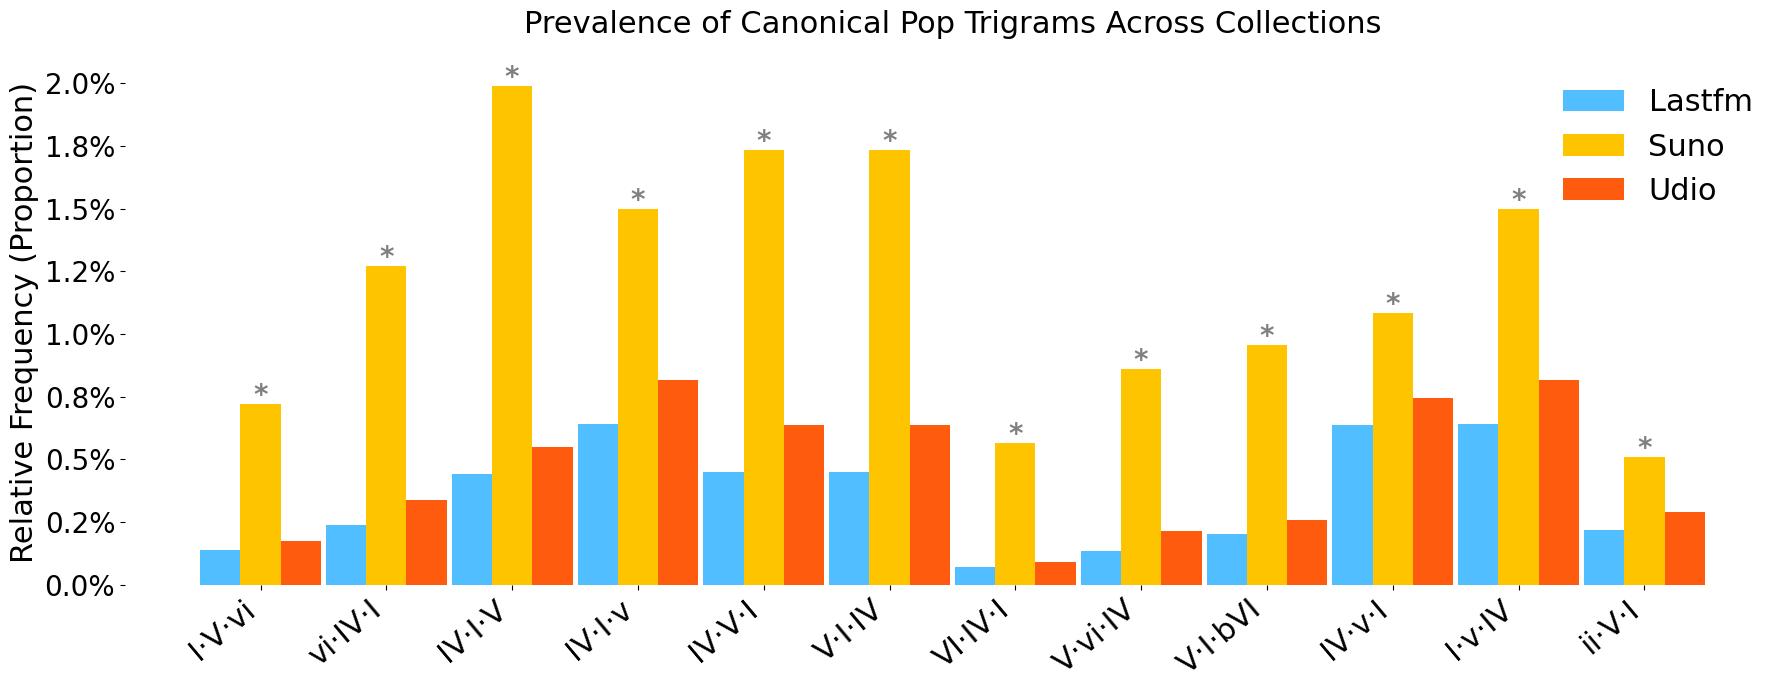

I-V-vi: Suno/Lastfm ratio: 5.19, Suno/Udio ratio: 4.10
vi-IV-I: Suno/Lastfm ratio: 5.32, Suno/Udio ratio: 3.77
IV-I-V: Suno/Lastfm ratio: 4.50, Suno/Udio ratio: 3.62
IV-I-v: Suno/Lastfm ratio: 2.34, Suno/Udio ratio: 1.84
IV-V-I: Suno/Lastfm ratio: 3.85, Suno/Udio ratio: 2.72
V-I-IV: Suno/Lastfm ratio: 3.85, Suno/Udio ratio: 2.72
VI-IV-I: Suno/Lastfm ratio: 8.06, Suno/Udio ratio: 6.17
V-vi-IV: Suno/Lastfm ratio: 6.30, Suno/Udio ratio: 4.02
V-I-bVI: Suno/Lastfm ratio: 4.71, Suno/Udio ratio: 3.71
IV-v-I: Suno/Lastfm ratio: 1.70, Suno/Udio ratio: 1.46
I-v-IV: Suno/Lastfm ratio: 2.34, Suno/Udio ratio: 1.84
ii-V-I: Suno/Lastfm ratio: 2.33, Suno/Udio ratio: 1.76


In [111]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# Prepare the data
trigram_names = [row['Trigram'].replace('-', '·') for row in trigram_results]
collections = ['lastfm', 'suno', 'udio']
proportions = {col: [row[f"{col}_prop"] for row in trigram_results] for col in collections}

# Bar width and positions
bar_width = 0.32
x = np.arange(len(trigram_names))

fig, ax = plt.subplots(figsize=(18, 7))
colors = ['#51BFFF', '#FFC400', '#FF5B0E']  # lastfm, suno, udio

for i, col in enumerate(collections):
    ax.bar(x + i * bar_width, proportions[col], width=bar_width, label=col.capitalize(), color=colors[i])

ax.set_xticks(x + bar_width)
ax.set_xticklabels(trigram_names, rotation=40, ha='right', fontsize=22)
ax.set_ylabel('Relative Frequency (Proportion)', fontsize=22)
ax.set_title('Prevalence of Canonical Pop Trigrams Across Collections', fontsize=22, pad=20)
ax.legend(title="", fontsize=22, title_fontsize=14, frameon=False)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))
ax.tick_params(axis='y', labelsize=20)

# Optionally annotate significant results
for i, row in enumerate(trigram_results):
    sig = (row['suno_vs_lastfm_p'] < 0.05) and (row['suno_vs_udio_p'] < 0.05)
    if sig:
        y = proportions['suno'][i]
        ax.text(x[i] + bar_width, y, '*', color='gray', ha='center', fontsize=20, fontweight='bold')


for spine in ax.spines.values():
    spine.set_visible(False)
    
plt.tight_layout()
plt.show()

for row in trigram_results:
    suno_prop = row["suno_prop"]
    lastfm_prop = row["lastfm_prop"]
    udio_prop = row["udio_prop"]
    suno_vs_lastfm_ratio = suno_prop / lastfm_prop if lastfm_prop else float('inf')
    suno_vs_udio_ratio = suno_prop / udio_prop if udio_prop else float('inf')
    print(f"{row['Trigram']}: Suno/Lastfm ratio: {suno_vs_lastfm_ratio:.2f}, Suno/Udio ratio: {suno_vs_udio_ratio:.2f}")



In [104]:
for row in trigram_results:
    suno_prop = row["suno_prop"]
    lastfm_prop = row["lastfm_prop"]
    udio_prop = row["udio_prop"]
    suno_vs_lastfm_ratio = suno_prop / lastfm_prop if lastfm_prop else float('inf')
    suno_vs_udio_ratio = suno_prop / udio_prop if udio_prop else float('inf')
    p_lastfm = row.get('suno_vs_lastfm_p', float('nan'))
    p_udio = row.get('suno_vs_udio_p', float('nan'))
    print(
        f"{row['Trigram']}: "
        f"Suno/Lastfm ratio: {suno_vs_lastfm_ratio:.2f} (p={p_lastfm:.2g}), "
        f"Suno/Udio ratio: {suno_vs_udio_ratio:.2f} (p={p_udio:.2g})"
    )


I-V-vi: Suno/Lastfm ratio: 5.19 (p=0), Suno/Udio ratio: 4.10 (p=0)
vi-IV-I: Suno/Lastfm ratio: 5.32 (p=0), Suno/Udio ratio: 3.77 (p=0)
IV-I-V: Suno/Lastfm ratio: 4.50 (p=0), Suno/Udio ratio: 3.62 (p=0)
IV-I-v: Suno/Lastfm ratio: 2.34 (p=0), Suno/Udio ratio: 1.84 (p=0)
IV-V-I: Suno/Lastfm ratio: 3.85 (p=0), Suno/Udio ratio: 2.72 (p=0)
V-I-IV: Suno/Lastfm ratio: 3.85 (p=0), Suno/Udio ratio: 2.72 (p=0)
VI-IV-I: Suno/Lastfm ratio: 8.06 (p=0), Suno/Udio ratio: 6.17 (p=0)
V-vi-IV: Suno/Lastfm ratio: 6.30 (p=0), Suno/Udio ratio: 4.02 (p=0)
V-I-bVI: Suno/Lastfm ratio: 4.71 (p=0), Suno/Udio ratio: 3.71 (p=0)
IV-v-I: Suno/Lastfm ratio: 1.70 (p=0), Suno/Udio ratio: 1.46 (p=4e-194)
I-v-IV: Suno/Lastfm ratio: 2.34 (p=0), Suno/Udio ratio: 1.84 (p=0)
ii-V-I: Suno/Lastfm ratio: 2.33 (p=0), Suno/Udio ratio: 1.76 (p=1.4e-186)
